<>:219: SyntaxWarning: invalid escape sequence '\e'
<>:219: SyntaxWarning: invalid escape sequence '\e'
/var/folders/vq/jyyc86k92_x3gh37zwr69l8c0000gn/T/ipykernel_36805/4198939323.py:219: SyntaxWarning: invalid escape sequence '\e'
  plot_regret_with_bound("$\ell_t(a) = g_t a, g_t \in \pm 1$", ftl_alt, ogd_alt, smart_alt, cfg.n)


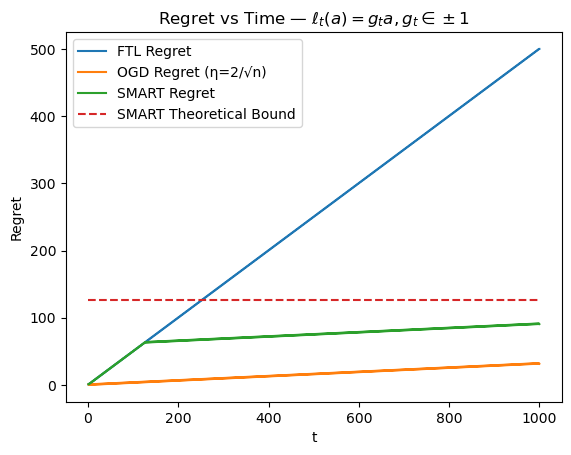

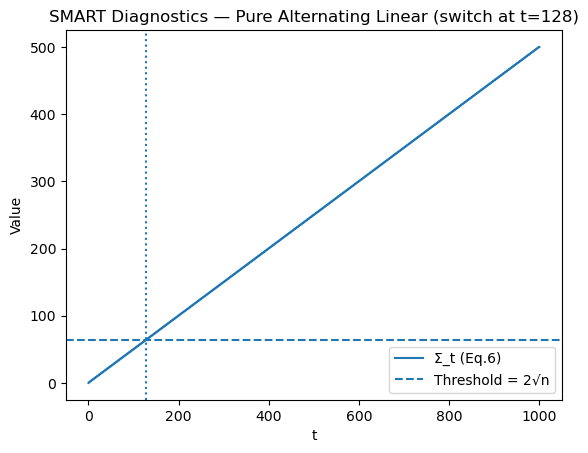

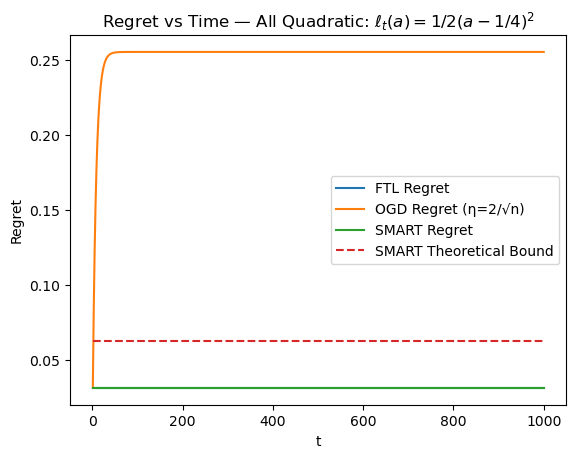

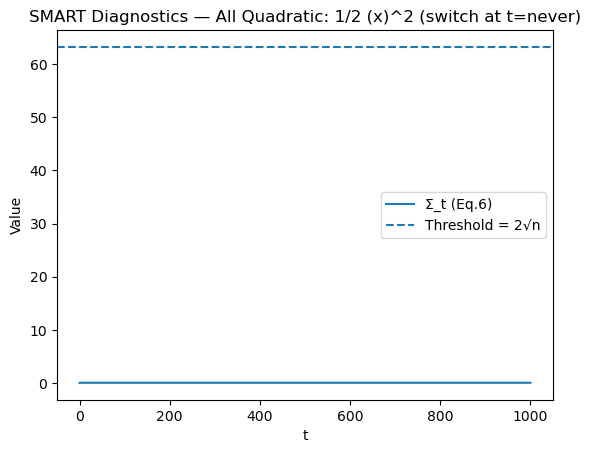

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import argparse

# -----------------------------
# Config and utilities
# -----------------------------

class Config:
    def __init__(self, n=1000, domain=(-1.0, 1.0), seed=0):
        self.n = int(n)
        self.domain = domain
        self.eta = 2.0 / np.sqrt(self.n)  # fixed step size
        self.rng = np.random.default_rng(seed)

def project_to_domain(x, domain):
    return min(max(x, domain[0]), domain[1])

# Evaluate loss value (up to ignored constants) and gradient
def eval_loss_and_grad(loss_t, x):
    if loss_t["type"] == "linear":
        g = loss_t["g"]
        return g * x, g
    elif loss_t["type"] == "quadratic":
        q = loss_t["q"]
        c = loss_t["c"]
        loss = 0.5 * q * x * x - q * c * x   # ignore constants (cancel in regret)
        grad = q * (x - c)
        return loss, grad
    else:
        raise ValueError("Unknown loss type")

# Aggregates track cumulative L_t(x) = 0.5*A_t x^2 + B_t x (constants omitted)
def update_aggregates(A, B, loss_t):
    if loss_t["type"] == "linear":
        return A, B + loss_t["g"]
    else:
        return A + loss_t["q"], B - loss_t["q"] * loss_t["c"]

def argmin_over_domain(A, B, domain):
    if A > 0:
        x_star = -B / A
    else:
        if B > 0:     x_star = -1.0
        elif B < 0:   x_star =  1.0
        else:         x_star =  0.0
    return project_to_domain(x_star, domain)

def hindsight_min_value(A, B):
    if A > 0:
        x_uncon = -B / A
        if -1.0 <= x_uncon <= 1.0:
            return -0.5 * (B * B) / A
    val_neg1 = 0.5 * A - B
    val_pos1 = 0.5 * A + B
    return min(val_neg1, val_pos1)

def S_value(A, B, x):
    return 0.5 * A * x * x + B * x

# -----------------------------
# Sequences
# -----------------------------

def make_linear_alternating(n):
    losses = []
    for t in range(1, n + 1):
        g = (-1.0) ** t
        losses.append({"type": "linear", "g": g})
    return losses

def make_quadratic_fixed(n, center=0.25, q=1.0):
    return [{"type": "quadratic", "q": q, "c": center} for _ in range(n)]

# -----------------------------
# Algorithms
# -----------------------------

def run_ftl(loss_seq, config):
    n = config.n
    A = 0.0
    B = 0.0
    x = np.zeros(n + 1)
    for t in range(1, n + 1):
        x[t] = argmin_over_domain(A, B, config.domain)
        A, B = update_aggregates(A, B, loss_seq[t - 1])
    cum_loss = np.zeros(n + 1)
    cum_best = np.zeros(n + 1)
    A = 0.0
    B = 0.0
    for t in range(1, n + 1):
        loss_t, _ = eval_loss_and_grad(loss_seq[t - 1], x[t])
        cum_loss[t] = cum_loss[t - 1] + loss_t
        A, B = update_aggregates(A, B, loss_seq[t - 1])
        best_val = hindsight_min_value(A, B)
        cum_best[t] = best_val
    regret = cum_loss - cum_best
    return {"x": x, "regret": regret}

def run_ogd(loss_seq, config):
    n = config.n
    eta = config.eta
    x = np.zeros(n + 1)
    for t in range(1, n):
        _, grad_t = eval_loss_and_grad(loss_seq[t - 1], x[t])
        x[t + 1] = project_to_domain(x[t] - eta * grad_t, config.domain)
    cum_loss = np.zeros(n + 1)
    cum_best = np.zeros(n + 1)
    A = 0.0
    B = 0.0
    for t in range(1, n + 1):
        loss_t, _ = eval_loss_and_grad(loss_seq[t - 1], x[t])
        cum_loss[t] = cum_loss[t - 1] + loss_t
        A, B = update_aggregates(A, B, loss_seq[t - 1])
        best_val = hindsight_min_value(A, B)
        cum_best[t] = best_val
    regret = cum_loss - cum_best
    return {"x": x, "regret": regret}

# Eq. (6): Σ_t = sum_{i=1}^t [ L_i(a^*_{i-1}) - L_i(a^*_i) ]
def compute_sigma_eq6(loss_seq, config):
    n = config.n
    A = 0.0
    B = 0.0
    a_star = np.zeros(n + 1)  # a*_0 = 0 (any point in [-1,1] is fine)
    Sigma = np.zeros(n + 1)
    for i in range(1, n + 1):
        A, B = update_aggregates(A, B, loss_seq[i - 1])
        a_star[i] = argmin_over_domain(A, B, config.domain)
        Li_prev = S_value(A, B, a_star[i - 1])
        Li_curr = S_value(A, B, a_star[i])
        Sigma[i] = Sigma[i - 1] + (Li_prev - Li_curr)
    return Sigma, a_star

def run_smart_deterministic(loss_seq, config):
    n = config.n
    ftl = run_ftl(loss_seq, config)
    ogd = run_ogd(loss_seq, config)
    Sigma, _ = compute_sigma_eq6(loss_seq, config)
    threshold = 2.0 * np.sqrt(n)

    switch_round = n + 1
    for t in range(1, n + 1):
        if Sigma[t] > threshold:
            switch_round = t + 1
            break

    x = np.zeros(n + 1)
    for t in range(1, n + 1):
        x[t] = ftl["x"][t] if t < switch_round else ogd["x"][t]

    cum_loss = np.zeros(n + 1)
    cum_best = np.zeros(n + 1)
    A = 0.0
    B = 0.0
    for t in range(1, n + 1):
        loss_t, _ = eval_loss_and_grad(loss_seq[t - 1], x[t])
        cum_loss[t] = cum_loss[t - 1] + loss_t
        A, B = update_aggregates(A, B, loss_seq[t - 1])
        best_val = hindsight_min_value(A, B)
        cum_best[t] = best_val
    regret = cum_loss - cum_best

    return {"x": x, "regret": regret, "Sigma_eq6": Sigma, "threshold": threshold, "switch_round": switch_round,
            "ftl": ftl, "ogd": ogd}

# -----------------------------
# Plotting
# -----------------------------

def plot_regret_with_bound(name, ftl, ogd, smart, n):
    t = np.arange(1, n + 1)
    ftl_regret = ftl["regret"][1:]
    ogd_regret = ogd["regret"][1:]
    smart_regret = smart["regret"][1:]
    bound_final = 2.0 * min(ftl_regret[-1], 2.0 * np.sqrt(n))
    bound_curve = np.full_like(t, bound_final, dtype=float)

    plt.figure()
    plt.plot(t, ftl_regret, label="FTL Regret")
    plt.plot(t, ogd_regret, label="OGD Regret (η=2/√n)")
    plt.plot(t, smart_regret, label="SMART Regret")
    plt.plot(t, bound_curve, linestyle="--", label="SMART Theoretical Bound")
    plt.xlabel("t")
    plt.ylabel("Regret")
    plt.title(f"Regret vs Time — {name}")
    plt.legend(loc="best")
    plt.show()

def plot_smart_diagnostics(name, smart, n):
    t = np.arange(0, n + 1)
    Sigma = smart["Sigma_eq6"]
    thr = smart["threshold"]
    sw = smart["switch_round"]

    plt.figure()
    plt.plot(t, Sigma, label="Σ_t (Eq.6)")
    plt.axhline(thr, linestyle="--", label="Threshold = 2√n")
    if 1 <= sw <= n:
        plt.axvline(sw, linestyle=":")
    plt.xlabel("t")
    plt.ylabel("Value")
    plt.title(f"SMART Diagnostics — {name} (switch at t={sw if sw<=n else 'never'})")
    plt.legend(loc="best")
    plt.show()

# -----------------------------
# Experiments
# -----------------------------

def run_experiments(n=1000):
    cfg = Config(n=n, seed=0)

    # 1) Pure alternating linear
    losses_alt = make_linear_alternating(cfg.n)
    ftl_alt = run_ftl(losses_alt, cfg)
    ogd_alt = run_ogd(losses_alt, cfg)
    smart_alt = run_smart_deterministic(losses_alt, cfg)
    plot_regret_with_bound("$\ell_t(a) = g_t a, g_t \in \pm 1$", ftl_alt, ogd_alt, smart_alt, cfg.n)
    plot_smart_diagnostics("Pure Alternating Linear", smart_alt, cfg.n)

    # 2) All-quadratic: 1/2 (x-center)^2
    losses_q = make_quadratic_fixed(cfg.n, center=0.25, q=1.0)
    ftl_q = run_ftl(losses_q, cfg)
    ogd_q = run_ogd(losses_q, cfg)
    smart_q = run_smart_deterministic(losses_q, cfg)
    plot_regret_with_bound(
    r"All Quadratic: $\ell_t(a) = 1/2(a-1/4)^2$",
    ftl_q, ogd_q, smart_q, cfg.n
)
    
    plot_smart_diagnostics("All Quadratic: 1/2 (x)^2", smart_q, cfg.n)

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--n", type=int, default=1000, help="Horizon length")
    args = parser.parse_args()
    run_experiments(n=args.n)

#### Uncomment to run    
if __name__ == "__main__":
    run_experiments(n=1000) 